## Modelos de Machine Learning: XGBoost / LightGBM, Sistema de Predicción Energética en Barcelona


> objetivo es comprobar si los modelos de árboles son capaces de capturar relaciones no lineales e interacciones.

### Principio de comparación justa

- el mismo split temporal (train 2019–2024 · validación ene–sep 2025 · test oct–nov 2025 intacto)
- métricas (R² primaria; MAE, RMSE, MAPE)
- horizontes de backtesting (24h, 48h, 72h)

> La diferencia clave frente a SARIMA: los árboles **no** modelan la dependencia temporal de
> forma implícita — dependen de las *features* (lags, calendario, clima) construidas en el notebook 04.



## Librerías

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pymongo import MongoClient
import warnings, time
import skforecast; print(skforecast.__version__)
from lightgbm import LGBMRegressor
import lightgbm as lgb
import shap
from skforecast.recursive import ForecasterRecursiveMultiSeries, ForecasterEquivalentDate
from skforecast.preprocessing import RollingFeatures
from skforecast.model_selection import (
    TimeSeriesFold,
    backtesting_forecaster_multiseries,
    bayesian_search_forecaster_multiseries,
)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


warnings.filterwarnings('ignore')

plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#D3D3D3'
plt.rcParams['grid.linewidth'] = 0.4
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Paleta
C1 = '#264653'; C2 = '#2A9D8F'; C3 = '#E9C46A'
C4 = '#F4A261'; C5 = '#E76F51'; C6 = '#A8DADC'
TITULO = '#1B3A5C'; SUBTITULO = '#C0392B'

start_time = time.time()

0.22.0


---
## Carga de datos

In [2]:
client = MongoClient('mongodb://mongo:27017/')
db     = client['tfm_energy']

docs = list(db['dataset_ml'].find({}, {'_id': 0}))
df_ml   = pl.DataFrame(docs, infer_schema_length=None)

print(f"Shape: {df_ml.shape}")
print(f"Desde: {df_ml['datetime'].min()}  Hasta: {df_ml['datetime'].max()}")
print(f"Codigos postales: {df_ml['cod_postal'].n_unique()}")
print(f"Columnas ({len(df_ml.columns)}):")
print(sorted(df_ml.columns))

Shape: (424368, 35)
Desde: 2019-01-01 00:00:00  Hasta: 2025-11-30 18:00:00
Codigos postales: 42
Columnas (35):
['CDD', 'HDD', 'anio', 'cdd_roll_3d', 'cod_postal', 'datetime', 'dia_semana', 'es_festivo', 'es_finde', 'hora', 'hora_x_finde', 'humedad_mean', 'irradiancia_mean', 'is_covid', 'lag_1', 'lag_2', 'lag_28', 'lag_3', 'lag_4', 'lst_celsius', 'lst_nublado', 'mes', 'mwh_total', 'pct_industria_cp', 'pct_residencial_cp', 'pct_servicios_cp', 'precipitacion_llueve', 'precipitacion_sum', 'rolling_mean_7d', 'rolling_std_7d', 'semana_anio', 'temp_max', 'temp_mean', 'temp_min', 'viento_mean']


---
# <font color='#1B3A5C'>  **1. Configuración del Experimento** </font>

> mismos cortes temporales y horizontes para que la comparación baseline vs. ML es justa. El conjunto de *test (oct–nov 2025)

In [3]:
# Identicos a SARIMA, SARIMAX)
INI       = '2019-01-01'             # historico completo
FIN_TRAIN = '2024-12-31 18:00:00'    # fin de train
FIN_VAL   = '2025-09-30 18:00:00'    # fin de validacion (2025-01 -> 2025-09)
# test: 2025-10-01 a  2025-11-30 (lo que queda tras FIN_VAL), INTACTO

#  4=24h, 8=48h, 12=72h
HORIZONTES = {'24h': 4, '48h': 8, '72h': 12}

TARGET = 'mwh_total'
# SOLO LIMPIOS (auditoria de calidad de datos, notebook 02): 12 CPs con target corrupto
# en val/test por reasignacion de OpenData -> excluidos. Quedan 30 limpios.
CPS_SUCIOS = ['08011','08009','08007','08013','08010','08006','08005',
              '08019','08008','08036','08026','08037']
CPS_TODOS = [cp for cp in sorted(df_ml['cod_postal'].unique().to_list()) if cp not in CPS_SUCIOS]

print(f"Train : {INI} -> {FIN_TRAIN}")
print(f"Val   : 2025-01-01 -> {FIN_VAL}")
print(f"Test  : 2025-10-01 -> {df_ml['datetime'].max()}  (intacto)")
print(f"Horizontes: {HORIZONTES}")
print(f"Target: {TARGET} | CPs: {len(CPS_TODOS)}")

Train : 2019-01-01 -> 2024-12-31 18:00:00
Val   : 2025-01-01 -> 2025-09-30 18:00:00
Test  : 2025-10-01 -> 2025-11-30 18:00:00  (intacto)
Horizontes: {'24h': 4, '48h': 8, '72h': 12}
Target: mwh_total | CPs: 42


### <font color='#C0392B'><b>1.1 Los cuatro roles de las variables</b></font>

> Hay que asignat a cada variable su papel para skforecast.

 - Identificadores datetime, cod_postal estructuran serie y tiempo.
 - Target mwh_total
- Autorregresivas lag_*, rolling_*_7d — se **descartan**; skforecast las regenera sin leakage
- Exógenascomo clima, calendario y perfil sectorial los regresores externos que sí entran.

In [4]:
LAGS = [1, 2, 3, 4, 28]
AUTOREG = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_28', 'rolling_mean_7d', 'rolling_std_7d']
NO_EXOG = ['datetime', 'cod_postal', TARGET] + AUTOREG
EXOG = [c for c in df_ml.columns if c not in NO_EXOG]

### <font color='#C0392B'><b>1.2 Construcción de las series multi-series</b></font>

> ForecasterRecursiveMultiSeries no recibe la tabla plana, sino las 42 series agrupadas por código postal.

 - series  y exog serán un diccionario por cada cosa.
 - Cada serie se reindexa a frecuencia de 6h (skforecast lo exige).
 - NaN residuales se mantienen, LightGBM los gestiona de forma nativa, ventaja frente a SARIMAX.


In [5]:
series = {}   # {cod_postal: pd.Series  (mwh_total, index 6h)}
exog   = {}   # {cod_postal: pd.DataFrame (EXOG, index 6h)}

for cp in CPS_TODOS:
    #Solo filas de ese barrio a pandas, la fecha es indice y marca fecuencia  a 6h
    g = (df_ml.filter(pl.col('cod_postal') == cp)
              .sort('datetime')
              .to_pandas()
              .set_index('datetime'))
    g.index = pd.DatetimeIndex(g.index)
    g = g.asfreq('6h') 

    #sanear exogenas booleanas para que funcione bien en los modelos de ML
    ex = g[EXOG].copy()
    bool_cols = ex.select_dtypes('bool').columns      
    ex[bool_cols] = ex[bool_cols].astype('int8')

    series[cp] = g[TARGET]
    exog[cp]   = ex

# Comprobación rápida
cp0 = CPS_TODOS[0]
print(f"Series: {len(series)} CPs")
print(f"{cp0}: {len(series[cp0])} bloques | exog {exog[cp0].shape} | "
      f"NaN exog: {int(exog[cp0].isna().sum().sum())}")
print("Columnas exog:", list(exog[cp0].columns))

print(series[cp0].head())
print(exog[cp0].head())

Series: 42 CPs
08001: 10104 bloques | exog (10104, 25) | NaN exog: 9197
Columnas exog: ['lst_celsius', 'temp_mean', 'temp_max', 'temp_min', 'humedad_mean', 'viento_mean', 'precipitacion_sum', 'irradiancia_mean', 'es_festivo', 'hora', 'dia_semana', 'mes', 'anio', 'semana_anio', 'es_finde', 'HDD', 'CDD', 'lst_nublado', 'precipitacion_llueve', 'cdd_roll_3d', 'hora_x_finde', 'is_covid', 'pct_industria_cp', 'pct_residencial_cp', 'pct_servicios_cp']
datetime
2019-01-01 00:00:00     68681.0
2019-01-01 06:00:00     84009.0
2019-01-01 12:00:00    101500.0
2019-01-01 18:00:00    105428.0
2019-01-02 00:00:00     64121.0
Freq: 6h, Name: mwh_total, dtype: float64
                     lst_celsius  temp_mean  temp_max  temp_min  humedad_mean  \
datetime                                                                        
2019-01-01 00:00:00        12.57   9.883333      11.1       8.8     59.166667   
2019-01-01 06:00:00        12.57  12.775000      15.4       9.5     61.750000   
2019-01-01 12:00:

> El resultado son dos diccionarios con los CP de key y sus respectivas variables de value.

---
# <font color='#1B3A5C'>  **2. Modelo base: LightGBM multi-series** </font>

> Primer modelo con hiperparámetros por defecto, para tener una referencia antes de optimizar.
- Un que aprende de los 42 CPs a la vez.
- RollingFeatures va a generar el rolling_mean y std 7 del feature engineering

In [6]:
rolling = RollingFeatures(stats=['mean', 'std'], window_sizes=28)   # 28 bloques = 7 días

forecaster = ForecasterRecursiveMultiSeries(
    estimator       = LGBMRegressor(random_state=12, verbose=-1),
    lags            = LAGS,
    window_features = rolling,
    encoding        = 'ordinal_category',
)
forecaster

============================== 
ForecasterRecursiveMultiSeries 
============================== 
Estimator: LGBMRegressor 
Lags: [ 1  2  3  4 28] 
Window features: ['roll_mean_28', 'roll_std_28'] 
Window size: 28 
Series encoding: ordinal_category 
Series names (levels): None 
Exogenous included: False 
Exogenous names: None 
Categorical features: auto 
Transformer for series: None 
Transformer for exog: None 
Weight function included: False 
Series weights: None 
Differentiation order: None 
Drop NaN from series: False 
Training range: None 
Training index type: None 
Training index frequency: None 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 12, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-10 16:44:50 
Last fit date: None 
Skforecast version: 0.22.0 
Python version: 3.11.15 
Forecaster id: None

In [7]:
def metricas(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    denom = np.where(y_true == 0, np.nan, y_true)
    return {
        'r2'  : r2_score(y_true, y_pred),
        'mae' : mean_absolute_error(y_true, y_pred),
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mape': float(np.nanmean(np.abs((y_true - y_pred) / denom)) * 100),
    }

#### Base line: Entrenamiento sin hiperparámetros

In [8]:
series_val = {cp: s.loc[:FIN_VAL] for cp, s in series.items()}
exog_val   = {cp: e.loc[:FIN_VAL] for cp, e in exog.items()}

fin_train_idx = len(series[CPS_TODOS[0]].loc[:FIN_TRAIN])

cv_val = TimeSeriesFold(steps=12, initial_train_size=fin_train_idx, refit=False)


metrica_sk, predicciones = backtesting_forecaster_multiseries(
    forecaster = forecaster,
    series     = series_val,
    exog       = exog_val,
    cv         = cv_val,
    metric     = 'mean_absolute_error',   # obligatorio pasar una; la ignoraremos
    add_aggregated_metric = False,
    verbose    = False,
)


print("predicciones:", predicciones.shape)
print(predicciones.head())

  0%|          | 0/91 [00:00<?, ?it/s]

predicciones: (45864, 3)
            level  fold          pred
2025-01-01  08001     0  59682.879477
2025-01-01  08002     0  51180.929312
2025-01-01  08003     0  93242.688956
2025-01-01  08004     0  95729.026021
2025-01-01  08005     0  91818.040952


### <font color="#C0392B"><b>2.1 Revisión de resultados (función reutilizable)</b></font>

> `revisar_resultados()` reúne en una sola llamada toda la diagnosis del modelo desde su backtest:
> métricas por CP (R² primaria), R² por barrio, predicho vs real, error por horizonte, error por
> hora/día, curva train/val, importancia nativa y **SHAP**. Se reutilizará igual sobre el modelo
> tuneado, para comparar de forma homogénea.

In [15]:
def revisar_resultados(predicciones, series_val, forecaster, exog_val,
                       nombre='LightGBM', excluir=(),
                       cps_demo=('08002', '08013', '08039'),
                       ventana=('2025-03-01', '2025-03-31'),
                       shap_on=True, shap_sample=3000):
    """Dashboard de revisión de un modelo desde su backtest. Devuelve ml_val."""
    cps = sorted(predicciones['level'].unique())

    # ---------- cálculos ----------
    # métricas por CP
    filas = []
    for cp in cps:
        p = predicciones.loc[predicciones['level'] == cp, 'pred'].sort_index()
        y = series_val[cp].reindex(p.index)
        m = metricas(y.values, p.values); m['cp'] = cp; filas.append(m)
    ml_val = pd.DataFrame(filas)
    val = ml_val[~ml_val['cp'].isin(excluir)]

    # error por horizonte
    err = []
    for cp in cps:
        if cp in excluir:
            continue
        sub = predicciones[predicciones['level'] == cp].sort_index().copy()
        sub['ae']   = np.abs(series_val[cp].reindex(sub.index).values - sub['pred'].values)
        sub['step'] = sub.groupby('fold').cumcount() + 1
        err.append(sub[['step', 'ae']])
    curva = pd.concat(err).groupby('step')['ae'].mean()

    # error por hora / día
    tt = []
    for cp in cps:
        if cp in excluir:
            continue
        sub = predicciones[predicciones['level'] == cp].sort_index()
        tt.append(pd.DataFrame({'ae': np.abs(series_val[cp].reindex(sub.index).values - sub['pred'].values)}, index=sub.index))
    tt = pd.concat(tt); tt['hora'] = tt.index.hour; tt['dia'] = tt.index.dayofweek

    # curva train/val + importancia (reentrena un LGBM con los params del forecaster)
    out = forecaster.create_train_X_y(series=series_val, exog=exog_val)
    X_all, y_all = out[0], out[1]
    mtr = X_all.index <= FIN_TRAIN
    X_tr, y_tr, X_va, y_va = X_all[mtr], y_all[mtr], X_all[~mtr], y_all[~mtr]
    reg_base = getattr(forecaster, 'regressor', None) or getattr(forecaster, 'estimator', None)
    reg = LGBMRegressor(**reg_base.get_params())
    reg.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_va, y_va)],
            eval_names=['train', 'val'], eval_metric='rmse', callbacks=[lgb.log_evaluation(0)])
    ev  = reg.evals_result_
    imp = pd.Series(reg.feature_importances_, index=X_tr.columns).sort_values(ascending=False)

    # ---------- resumen numérico ----------
    print(f"=== {nombre} — validación, {len(val)} CPs limpios ===")
    print(f"R² mediana: {val['r2'].median():.3f} | media: {val['r2'].mean():.3f}")
    print(val[['r2', 'mae', 'rmse', 'mape']].describe().round(2))

    # ========== FIGURA 1: dashboard ==========
    fig = plt.figure(figsize=(18, 15))
    gs  = fig.add_gridspec(4, 3, width_ratios=[1.2, 1.1, 1.1], hspace=0.5, wspace=0.28)
    fig.suptitle(f'{nombre} — diagnóstico (validación)', fontsize=16, fontweight='bold', color=TITULO)

    # (col izq) R² por CP
    axR = fig.add_subplot(gs[:, 0])
    b = ml_val.sort_values('r2')
    col = [C5 if r < 0.4 else (C3 if r < 0.6 else C1) for r in b['r2']]
    axR.barh(b['cp'], b['r2'], color=col, edgecolor='white')
    axR.axvline(val['r2'].median(), color='gray', lw=1, ls='--')
    axR.set_xlabel('R²'); axR.set_title('R² por código postal', fontsize=11, color=TITULO)
    axR.tick_params(labelsize=8)

    # (col centro) 4 diagnósticos apilados
    axC = fig.add_subplot(gs[0, 1])
    axC.plot(ev['train']['rmse'], label='train', color=C1)
    axC.plot(ev['val']['rmse'], label='val', color=C5)
    axC.set_title('Curva train vs val', fontsize=11, color=TITULO)
    axC.set_xlabel('nº árboles'); axC.set_ylabel('RMSE'); axC.legend(fontsize=8)

    axH = fig.add_subplot(gs[1, 1])
    axH.plot(curva.index * 6, curva.values, marker='o', color=C5)
    axH.set_title('Error por horizonte', fontsize=11, color=TITULO)
    axH.set_xlabel('horas'); axH.set_ylabel('MAE')

    axHo = fig.add_subplot(gs[2, 1])
    tt.groupby('hora')['ae'].mean().plot(kind='bar', ax=axHo, color=C1, edgecolor='white')
    axHo.set_title('MAE por hora del día', fontsize=11, color=TITULO)
    axHo.set_xlabel('hora'); axHo.set_ylabel('MAE'); axHo.tick_params(axis='x', rotation=0)

    axD = fig.add_subplot(gs[3, 1])
    tt.groupby('dia')['ae'].mean().plot(kind='bar', ax=axD, color=C4, edgecolor='white')
    axD.set_title('MAE por día (0=Lun … 6=Dom)', fontsize=11, color=TITULO)
    axD.set_xlabel('día'); axD.set_ylabel('MAE'); axD.tick_params(axis='x', rotation=0)

    # (col der) importancia
    axI = fig.add_subplot(gs[:, 2])
    imp.head(20)[::-1].plot(kind='barh', ax=axI, color=C1, edgecolor='white')
    axI.set_title('Importancia nativa (top 20)', fontsize=11, color=TITULO)
    axI.tick_params(labelsize=8)

    plt.show()

    # ========== FIGURA 2: predicho vs real ==========
    sl = slice(*ventana)
    fig, axes = plt.subplots(len(cps_demo), 1, figsize=(13, 7), sharex=True)
    for axx, cp in zip(np.atleast_1d(axes), cps_demo):
        real = series_val[cp].loc[sl]
        pred = predicciones.loc[predicciones['level'] == cp, 'pred'].sort_index().loc[sl]
        axx.plot(real.index, real.values, color=C1, lw=1.2, label='real')
        axx.plot(pred.index, pred.values, color=C5, lw=1.2, ls='--', label='predicho')
        r2cp = ml_val.loc[ml_val['cp'] == cp, 'r2'].values[0]
        axx.set_title(f'{cp} (R²={r2cp:.2f})', fontsize=10, color=TITULO); axx.set_ylabel('MWh')
    np.atleast_1d(axes)[0].legend(loc='upper right', fontsize=8)
    fig.suptitle(f'{nombre} — predicho vs real ({ventana[0]} a {ventana[1]})', fontweight='bold', color=TITULO)
    plt.tight_layout(); plt.show()

    # ========== FIGURA 3: SHAP ==========
    if shap_on:
        Xs = X_va.sample(min(shap_sample, len(X_va)), random_state=12)
        try:
            sv = shap.TreeExplainer(reg).shap_values(Xs)
            shap.summary_plot(sv, Xs, max_display=20, show=True)
        except Exception as e:
            print('SHAP: reintento con categóricas->códigos por:', str(e)[:80])
            Xs2 = Xs.copy()
            for c in Xs2.select_dtypes('category').columns:
                Xs2[c] = Xs2[c].cat.codes
            sv = shap.TreeExplainer(reg).shap_values(Xs2)
            shap.summary_plot(sv, Xs2, max_display=20, show=True)

    return ml_val

=== LightGBM por defecto — validación, 41 CPs (sin 08037) ===
R² mediana: 0.594 | media: 0.565
          r2       mae      rmse    mape
count  41.00     41.00     41.00   41.00
mean    0.56  13261.42  22027.54   43.27
std     0.14   5860.69   9642.70   68.12
min     0.22   6493.31  10420.49   13.31
25%     0.50   9208.47  15296.81   17.25
50%     0.59  12158.86  19868.42   20.07
75%     0.64  14780.07  25455.39   25.65
max     0.78  29870.51  50763.11  299.17


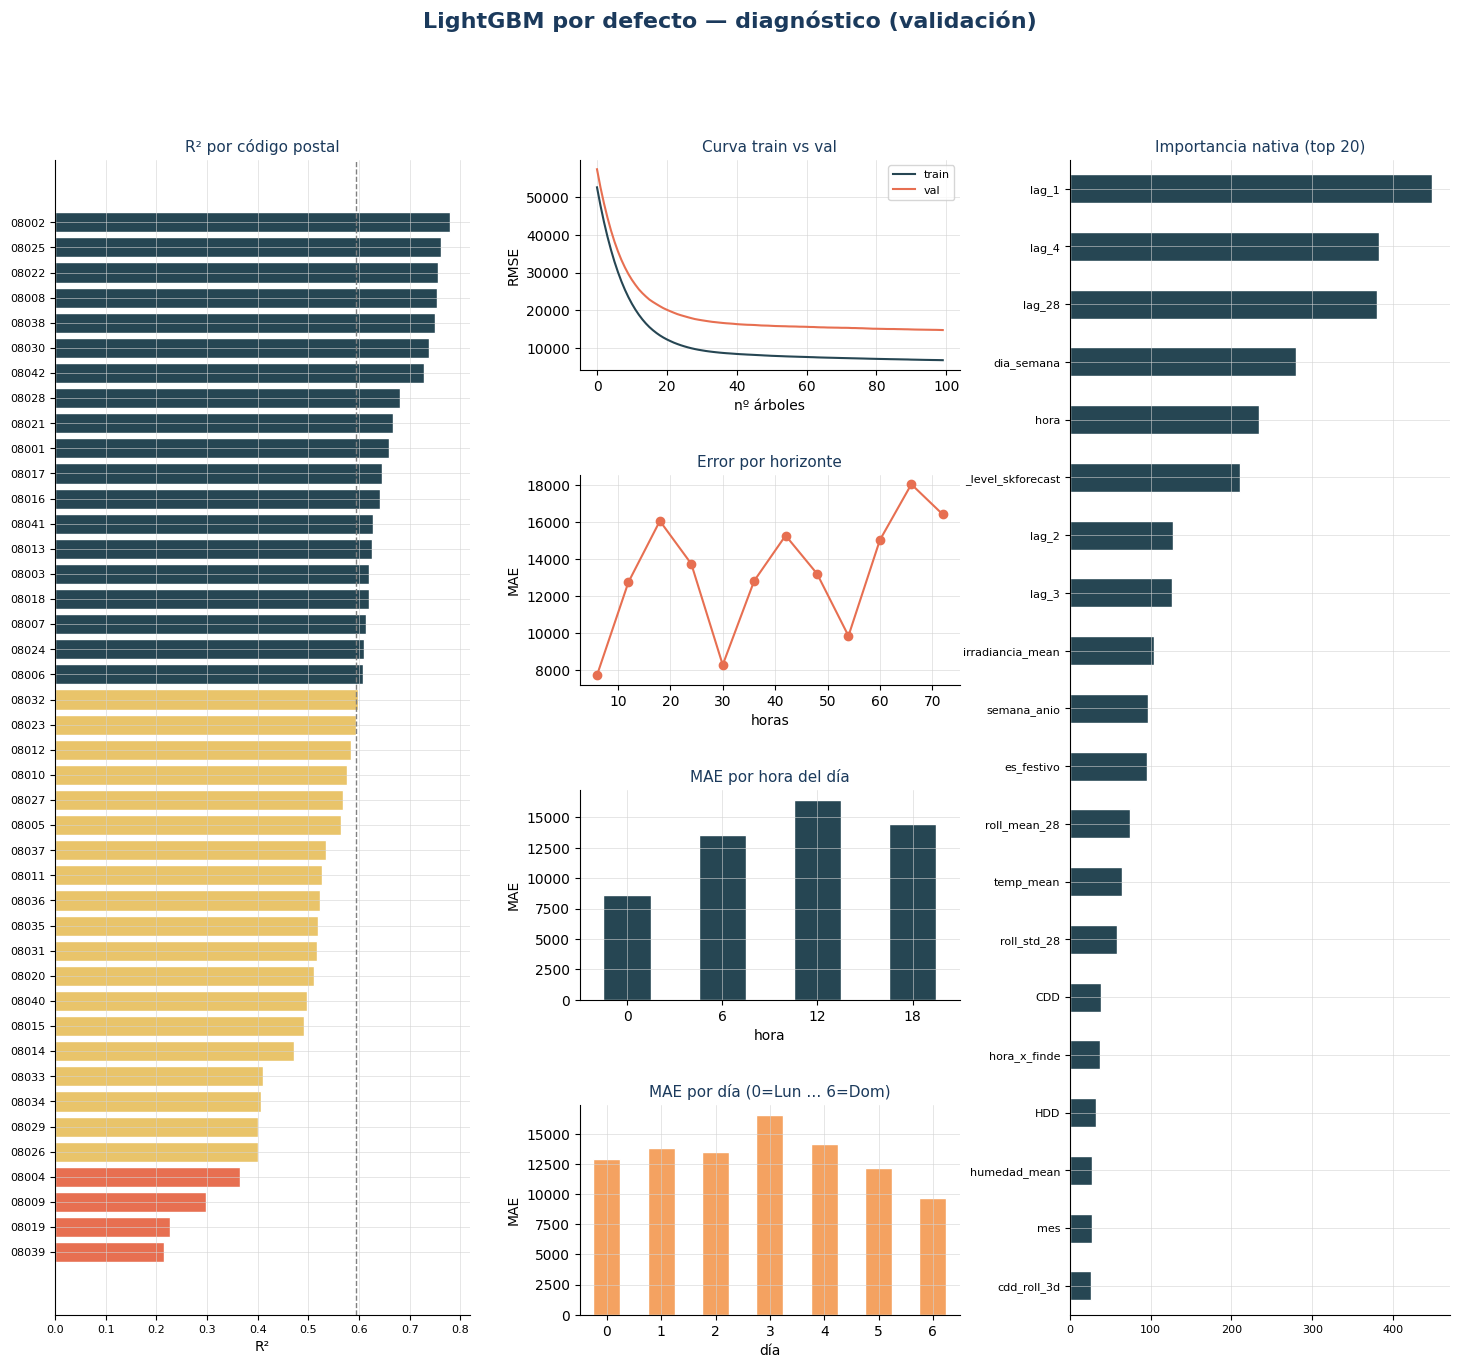

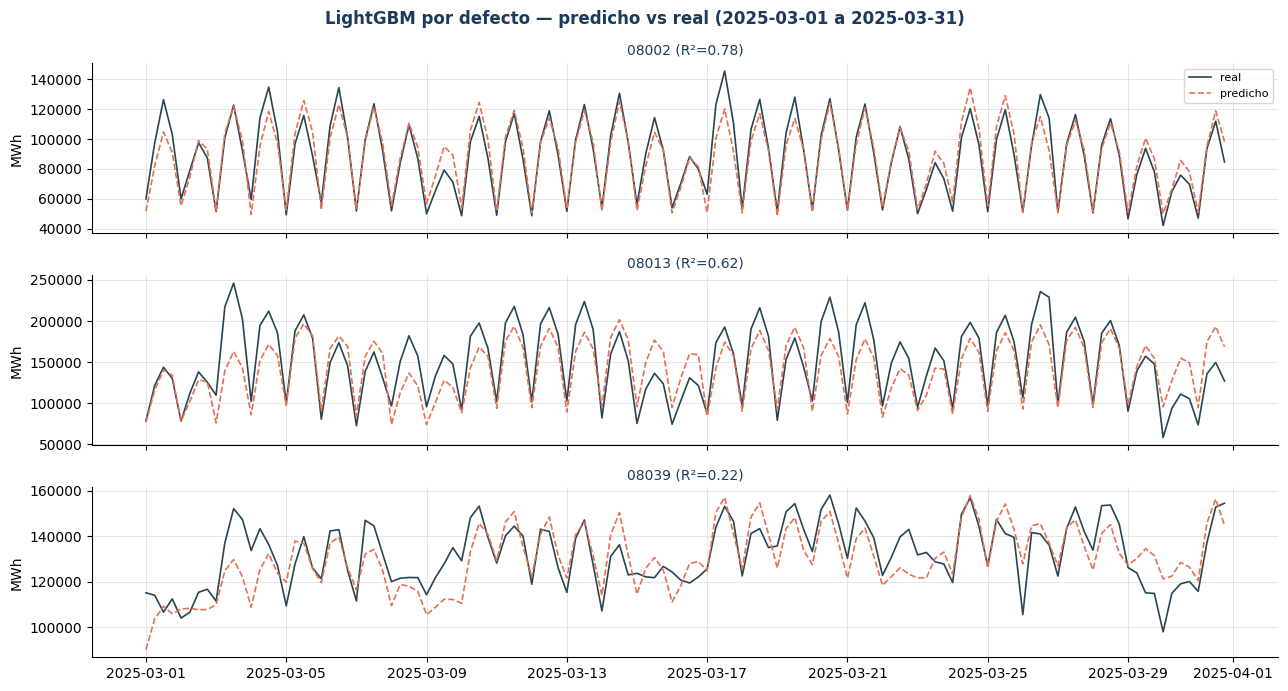

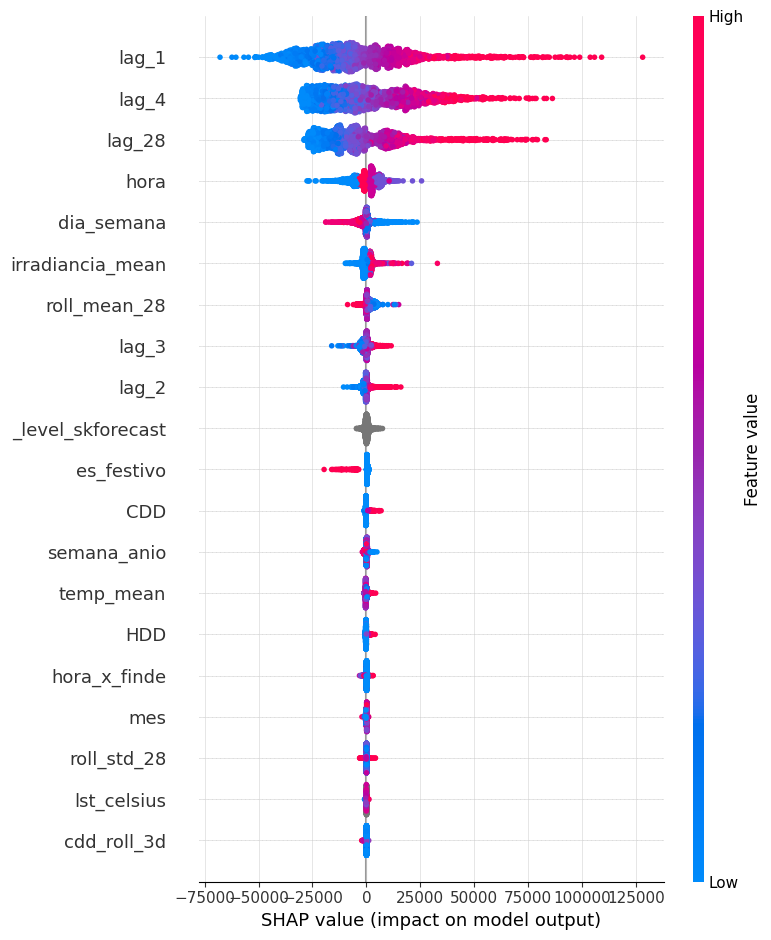

In [16]:
ml_val = revisar_resultados(predicciones, series_val, forecaster, exog_val, nombre='LightGBM por defecto')

### <font color='#C0392B'><b>2.2 Lectura del modelo por defecto</b></font>

> Sin tunear, el modelo deja una referencia de R² mediana = 0.59 y ya revela dónde acierta y dónde cojea.

 - Manda la autorregresión: SHAP e importancia coinciden — `lag_1`, `lag_4` (24h) y `lag_28` (semanal) son los que más pesan, justo lo que decía el ACF/PACF del EDA.
 - El barrio importa: `_level_skforecast` (la identidad del CP) aparece alto → el modelo global sí aprende las diferencias entre barrios.
 - Calendario sí, clima de fondo: `hora` y `dia_semana` pesan; el clima (`irradiancia`, `temp_mean`, `CDD`) aporta menos.
 - Candidatas a poda: `hora_x_finde`, `cdd_roll_3d` y el perfil sectorial quedan abajo en SHAP (el barrio ya los absorbe).
 - Curva train vs val: las líneas se separan, hay algo de overfitting; el val se aplana hacia 20 árboles. Margen claro para el tuning.
 - Error por horizonte: crece de 6h a 72h (predecir más lejos cuesta más), importante para multihorizonte
 - Cuándo falla: el bloque de mediodía (12:00) y los días entre semana son los más difíciles; noche y domingo, los fáciles.
 - Los barrios grandes/industriales fueron mejores (08002, 08038); Los complicados son los abrrios pequeños y volátiles (08039, 08019, 08009).

---
# <font color='#1B3A5C'>  **3.Optimización** </font>

In [17]:
# Importa la búsqueda grid (la bayesiana ya está importada arriba)
from skforecast.model_selection import grid_search_forecaster_multiseries

# Métrica a optimizar: -R² (skforecast minimiza, y R² hay que maximizar)
def neg_r2(y_true, y_pred):
    return -r2_score(y_true, y_pred)
neg_r2.__name__ = 'neg_r2'

# CV de la búsqueda: entrena hasta FIN_TRAIN, valida ene-sep 2025 a 72h (igual que el base)
fin_train_idx = len(series[CPS_TODOS[0]].loc[:FIN_TRAIN])
cv_tune = TimeSeriesFold(steps=12, initial_train_size=fin_train_idx, refit=False)

# Dos juegos de lags a probar (el del EDA, y uno ampliado con el eco semanal lag_56)
LAGS_BASE = [1, 2, 3, 4, 28]
LAGS_EXT  = [1, 2, 3, 4, 28, 56]

print("Setup de tuning listo. Métrica: neg_r2 (= -R²). CV: 72h sobre validación.")

Setup de tuning listo. Métrica: neg_r2 (= -R²). CV: 72h sobre validación.


In [ ]:
# Rejilla de hiperparámetros (pequeña: 2x2x2 = 8 combinaciones de params)
param_grid = {
    'n_estimators':  [300, 600],
    'max_depth':     [5, 10],
    'learning_rate': [0.05, 0.1],
}
lags_grid = [LAGS_BASE, LAGS_EXT]      # x2 juegos de lags -> 16 combinaciones en total

resultados_grid = grid_search_forecaster_multiseries(
    forecaster    = forecaster,
    series        = series_val,
    exog          = exog_val,
    cv            = cv_tune,
    param_grid    = param_grid,
    lags_grid     = lags_grid,
    metric        = neg_r2,
    return_best   = False,        # NO best_model directo (regla de José)
    verbose       = False,
    show_progress = True,
)


lags grid:   0%|          | 0/2 [00:00<?, ?it/s]

params grid:   0%|          | 0/8 [00:00<?, ?it/s]

params grid:   0%|          | 0/8 [00:00<?, ?it/s]

KeyError: 'neg_r2'

In [20]:

# Guardar TODO en CSV (directiva José) + R2 legible
resultados_grid['r2_val'] = -resultados_grid['neg_r2__average']
resultados_grid.to_csv('grid_lightgbm.csv', index=False)

print(f"Grid: {len(resultados_grid)} combinaciones -> grid_lightgbm.csv")
print(resultados_grid[['lags_label', 'learning_rate', 'max_depth', 'n_estimators', 'r2_val']]
      .head(10).to_string(index=False))

Grid: 16 combinaciones -> grid_lightgbm.csv
          lags_label  learning_rate  max_depth  n_estimators   r2_val
[1, 2, 3, 4, 28, 56]           0.10       10.0         600.0 0.590265
[1, 2, 3, 4, 28, 56]           0.05        5.0         300.0 0.588435
    [1, 2, 3, 4, 28]           0.10       10.0         600.0 0.582564
    [1, 2, 3, 4, 28]           0.05        5.0         300.0 0.579722
[1, 2, 3, 4, 28, 56]           0.05       10.0         600.0 0.578779
[1, 2, 3, 4, 28, 56]           0.05       10.0         300.0 0.576971
[1, 2, 3, 4, 28, 56]           0.10       10.0         300.0 0.575889
[1, 2, 3, 4, 28, 56]           0.10        5.0         600.0 0.568648
    [1, 2, 3, 4, 28]           0.05       10.0         300.0 0.561887
[1, 2, 3, 4, 28, 56]           0.05        5.0         600.0 0.560863


#### Bayesian

In [ ]:
# Espacio de búsqueda: rangos en vez de valores fijos
def search_space(trial):
    return {
        'n_estimators':  trial.suggest_int('n_estimators', 200, 800, step=100),
        'max_depth':     trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':    trial.suggest_int('num_leaves', 31, 200),
        'reg_alpha':     trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':    trial.suggest_float('reg_lambda', 0.0, 1.0),
        'lags':          trial.suggest_categorical('lags', [LAGS_BASE, LAGS_EXT]),
    }

resultados_bayes, best_trial = bayesian_search_forecaster_multiseries(
    forecaster    = forecaster,
    series        = series_val,
    exog          = exog_val,
    cv            = cv_tune,
    search_space  = search_space,
    metric        = neg_r2,
    n_trials      = 20,
    return_best   = False,        # otra vez: no best_model directo (regla José)
    verbose       = False,
    show_progress = True,
)


  0%|          | 0/20 [00:00<?, ?it/s]

Bayesiana: 20 pruebas -> bayes_lightgbm.csv


KeyError: "['lags_label'] not in index"

In [22]:
print(resultados_bayes.columns.tolist())
cols = [c for c in ['lags', 'lags_label', 'params', 'r2_val'] if c in resultados_bayes.columns]
print(resultados_bayes[cols].head(10).to_string(index=False))

['trial_number', 'levels', 'lags', 'params', 'neg_r2__weighted_average', 'neg_r2__average', 'neg_r2__pooling', 'n_estimators', 'max_depth', 'learning_rate', 'num_leaves', 'reg_alpha', 'reg_lambda', 'r2_val']
                lags                                                                                                                                                              params   r2_val
[1, 2, 3, 4, 28, 56] {'n_estimators': 600, 'max_depth': 10, 'learning_rate': 0.09540921004394595, 'num_leaves': 100, 'reg_alpha': 0.9320996395203449, 'reg_lambda': 0.09203272236938609} 0.617834
[1, 2, 3, 4, 28, 56]   {'n_estimators': 400, 'max_depth': 10, 'learning_rate': 0.14624722244644933, 'num_leaves': 78, 'reg_alpha': 0.7870410296163004, 'reg_lambda': 0.6104976936092701} 0.606854
[1, 2, 3, 4, 28, 56]     {'n_estimators': 600, 'max_depth': 7, 'learning_rate': 0.2281752216636079, 'num_leaves': 39, 'reg_alpha': 0.6561624143138154, 'reg_lambda': 0.8858020034192705} 0.606728
    [1, 2, 3, 4,

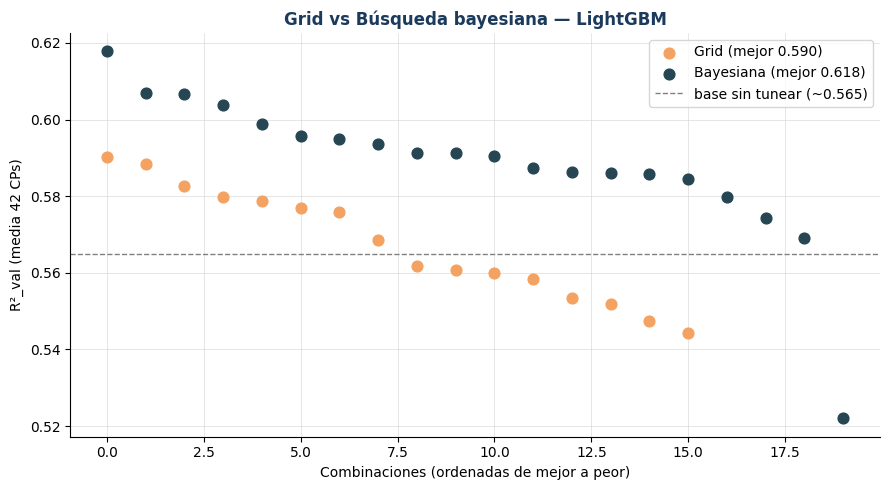

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(range(len(resultados_grid)),  sorted(resultados_grid['r2_val'],  reverse=True),
           label=f'Grid (mejor {resultados_grid["r2_val"].max():.3f})', color=C4, s=60, zorder=3)
ax.scatter(range(len(resultados_bayes)), sorted(resultados_bayes['r2_val'], reverse=True),
           label=f'Bayesiana (mejor {resultados_bayes["r2_val"].max():.3f})', color=C1, s=60, zorder=3)
ax.axhline(0.565, color='gray', ls='--', lw=1, label='base sin tunear (~0.565)')
ax.set_xlabel('Combinaciones (ordenadas de mejor a peor)')
ax.set_ylabel('R²_val (media 42 CPs)')
ax.set_title('Grid vs Búsqueda bayesiana — LightGBM', fontweight='bold', color=TITULO)
ax.legend(); plt.tight_layout(); plt.show()

In [24]:
# Ganador de la bayesiana
best = resultados_bayes.iloc[0]
best_params, best_lags = best['params'], best['lags']
print("Ganador:", best_params, "\nlags:", best_lags)

forecaster_tuned = ForecasterRecursiveMultiSeries(
    estimator       = LGBMRegressor(random_state=12, verbose=-1, **best_params),
    lags            = best_lags,
    window_features = rolling,
    encoding        = 'ordinal_category',
)

Ganador: {'n_estimators': 600, 'max_depth': 10, 'learning_rate': 0.09540921004394595, 'num_leaves': 100, 'reg_alpha': 0.9320996395203449, 'reg_lambda': 0.09203272236938609} 
lags: [ 1  2  3  4 28 56]


In [26]:
# Helper: R² mediano entre CPs (sin 08037), desde unas predicciones de backtest
def r2_mediano(pred, series_ref, excluir=()):
    rs = []
    for cp in sorted(pred['level'].unique()):
        if cp in excluir:
            continue
        p = pred.loc[pred['level'] == cp, 'pred'].sort_index()
        y = series_ref[cp].reindex(p.index)
        rs.append(metricas(y.values, p.values)['r2'])
    return float(np.median(rs))

# R²_val: entrena hasta 2024 -> backtest validación 2025
idx_2024 = len(series[CPS_TODOS[0]].loc[:FIN_TRAIN])
cv_v = TimeSeriesFold(steps=12, initial_train_size=idx_2024, refit=False)
_, pred_val = backtesting_forecaster_multiseries(
    forecaster_tuned, series=series_val, exog=exog_val, cv=cv_v,
    metric='mean_absolute_error', add_aggregated_metric=False, verbose=False, show_progress=False)

# R²_train: entrena hasta 2023 -> backtest 2024 (dentro de train)
FIN_2023 = '2023-12-31 18:00:00'
series_tr = {cp: s.loc[:FIN_TRAIN] for cp, s in series.items()}
exog_tr   = {cp: e.loc[:FIN_TRAIN] for cp, e in exog.items()}
idx_2023  = len(series[CPS_TODOS[0]].loc[:FIN_2023])
cv_t = TimeSeriesFold(steps=12, initial_train_size=idx_2023, refit=False)
_, pred_tr = backtesting_forecaster_multiseries(
    forecaster_tuned, series=series_tr, exog=exog_tr, cv=cv_t,
    metric='mean_absolute_error', add_aggregated_metric=False, verbose=False, show_progress=False)

r2_val   = r2_mediano(pred_val, series_val)
r2_train = r2_mediano(pred_tr,  series_tr)
rel_diff = (r2_train - r2_val) / abs(r2_train)

print(f"R²_train (2024): {r2_train:.3f}")
print(f"R²_val   (2025): {r2_val:.3f}")
print(f"rel_diff       : {rel_diff:.3f}  ->  {'OK, sin overfitting (<=0.10)' if rel_diff <= 0.10 else 'OJO: > 0.10'}")

R²_train (2024): 0.731
R²_val   (2025): 0.634
rel_diff       : 0.133  ->  OJO: > 0.10


In [27]:
def evaluar_candidato(params, lags):
    fc = ForecasterRecursiveMultiSeries(
        estimator=LGBMRegressor(random_state=12, verbose=-1, **params),
        lags=lags, window_features=rolling, encoding='ordinal_category')
    _, pv = backtesting_forecaster_multiseries(fc, series=series_val, exog=exog_val, cv=cv_v,
              metric='mean_absolute_error', add_aggregated_metric=False, verbose=False, show_progress=False)
    _, pt = backtesting_forecaster_multiseries(fc, series=series_tr, exog=exog_tr, cv=cv_t,
              metric='mean_absolute_error', add_aggregated_metric=False, verbose=False, show_progress=False)
    rt, rv = r2_mediano(pt, series_tr), r2_mediano(pv, series_val)
    return rt, rv, (rt - rv) / abs(rt)

filas = []
for i in range(6):
    c = resultados_bayes.iloc[i]
    rt, rv, rd = evaluar_candidato(c['params'], c['lags'])
    filas.append({'cand': i, 'r2_train': rt, 'r2_val': rv, 'rel_diff': rd,
                  'reg_alpha': round(c['params']['reg_alpha'], 2),
                  'max_depth': c['params']['max_depth']})
    print(f"cand {i}: R2_val={rv:.3f}  rel_diff={rd:.3f}")

cand = pd.DataFrame(filas)
print()
ok = cand[cand['rel_diff'] <= 0.10]
elegido = (ok if not ok.empty else cand).sort_values('r2_val', ascending=False).iloc[0]
print(f"ELEGIDO -> cand {int(elegido['cand'])}: R2_val={elegido['r2_val']:.3f}, rel_diff={elegido['rel_diff']:.3f}")

cand 0: R2_val=0.634  rel_diff=0.133
cand 1: R2_val=0.638  rel_diff=0.122
cand 2: R2_val=0.629  rel_diff=0.137
cand 3: R2_val=0.635  rel_diff=0.135
cand 4: R2_val=0.610  rel_diff=0.145
cand 5: R2_val=0.632  rel_diff=0.113

ELEGIDO -> cand 1: R2_val=0.638, rel_diff=0.122


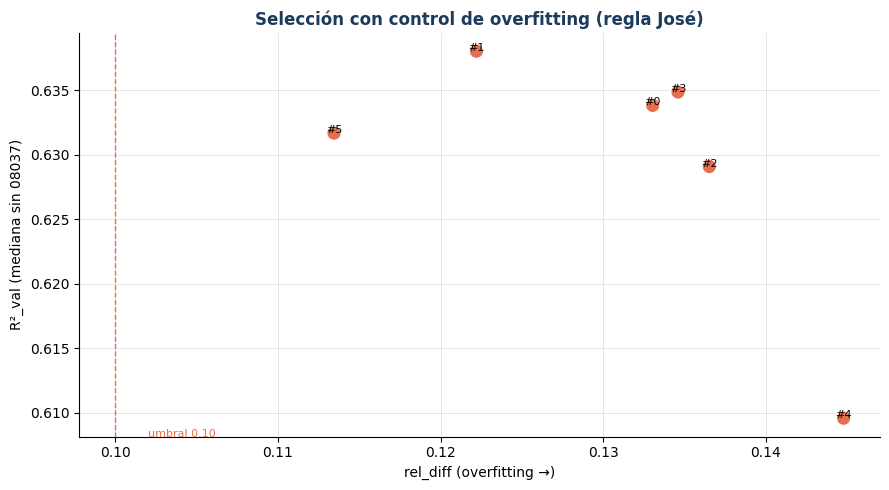

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
col = [C5 if r > 0.10 else C1 for r in cand['rel_diff']]
ax.scatter(cand['rel_diff'], cand['r2_val'], c=col, s=110, edgecolors='white', zorder=3)
for _, r in cand.iterrows():
    ax.annotate(f"#{int(r['cand'])}", (r['rel_diff'], r['r2_val']), fontsize=8, ha='center')
ax.axvline(0.10, color=C5, ls='--', lw=1); ax.text(0.102, ax.get_ylim()[0], 'umbral 0.10', color=C5, fontsize=8)
ax.set_xlabel('rel_diff (overfitting →)'); ax.set_ylabel('R²_val (mediana sin 08037)')
ax.set_title('Selección con control de overfitting (regla José)', fontweight='bold', color=TITULO)
plt.tight_layout(); plt.show()

#### Palanca escalado

In [29]:
from sklearn.preprocessing import StandardScaler

# Hiperparámetros del candidato elegido (cand 5)
elegido_params = resultados_bayes.iloc[5]['params']
elegido_lags   = resultados_bayes.iloc[5]['lags']

# Mismo modelo, pero escalando cada serie
forecaster_scaled = ForecasterRecursiveMultiSeries(
    estimator          = LGBMRegressor(random_state=12, verbose=-1, **elegido_params),
    lags               = elegido_lags,
    window_features    = rolling,
    encoding           = 'ordinal_category',
    transformer_series = StandardScaler(),     # <- escala cada serie por separado
)

# Backtest en validación (mismo cv de siempre)
_, pred_scaled = backtesting_forecaster_multiseries(
    forecaster_scaled, series=series_val, exog=exog_val, cv=cv_v,
    metric='mean_absolute_error', add_aggregated_metric=False, verbose=False, show_progress=False)

r2_scaled = r2_mediano(pred_scaled, series_val)
print(f"R²_val SIN escalado (cand 5): 0.632")
print(f"R²_val CON escalado        : {r2_scaled:.3f}")
print(f"Diferencia                 : {r2_scaled - 0.632:+.3f}")

R²_val SIN escalado (cand 5): 0.632
R²_val CON escalado        : 0.655
Diferencia                 : +0.023


In [30]:
_, pred_scaled_tr = backtesting_forecaster_multiseries(
    forecaster_scaled, series=series_tr, exog=exog_tr, cv=cv_t,
    metric='mean_absolute_error', add_aggregated_metric=False, verbose=False, show_progress=False)

rt_s = r2_mediano(pred_scaled_tr, series_tr)
print(f"Escalado -> R²_train={rt_s:.3f}  R²_val={r2_scaled:.3f}  rel_diff={(rt_s - r2_scaled)/abs(rt_s):.3f}")

Escalado -> R²_train=0.724  R²_val=0.655  rel_diff=0.095


=== LightGBM tuneado + escalado — validación, 41 CPs (sin 08037) ===
R² mediana: 0.655 | media: 0.606
          r2       mae      rmse    mape
count  41.00     41.00     41.00   41.00
mean    0.61  12470.94  20270.50   44.52
std     0.28   5730.76   9027.15   73.18
min    -0.97   5062.22   9404.99   12.34
25%     0.57   8668.01  14108.75   16.15
50%     0.66  11067.23  18754.57   19.50
75%     0.73  14735.45  22810.38   27.02
max     0.85  30976.51  48274.15  341.53


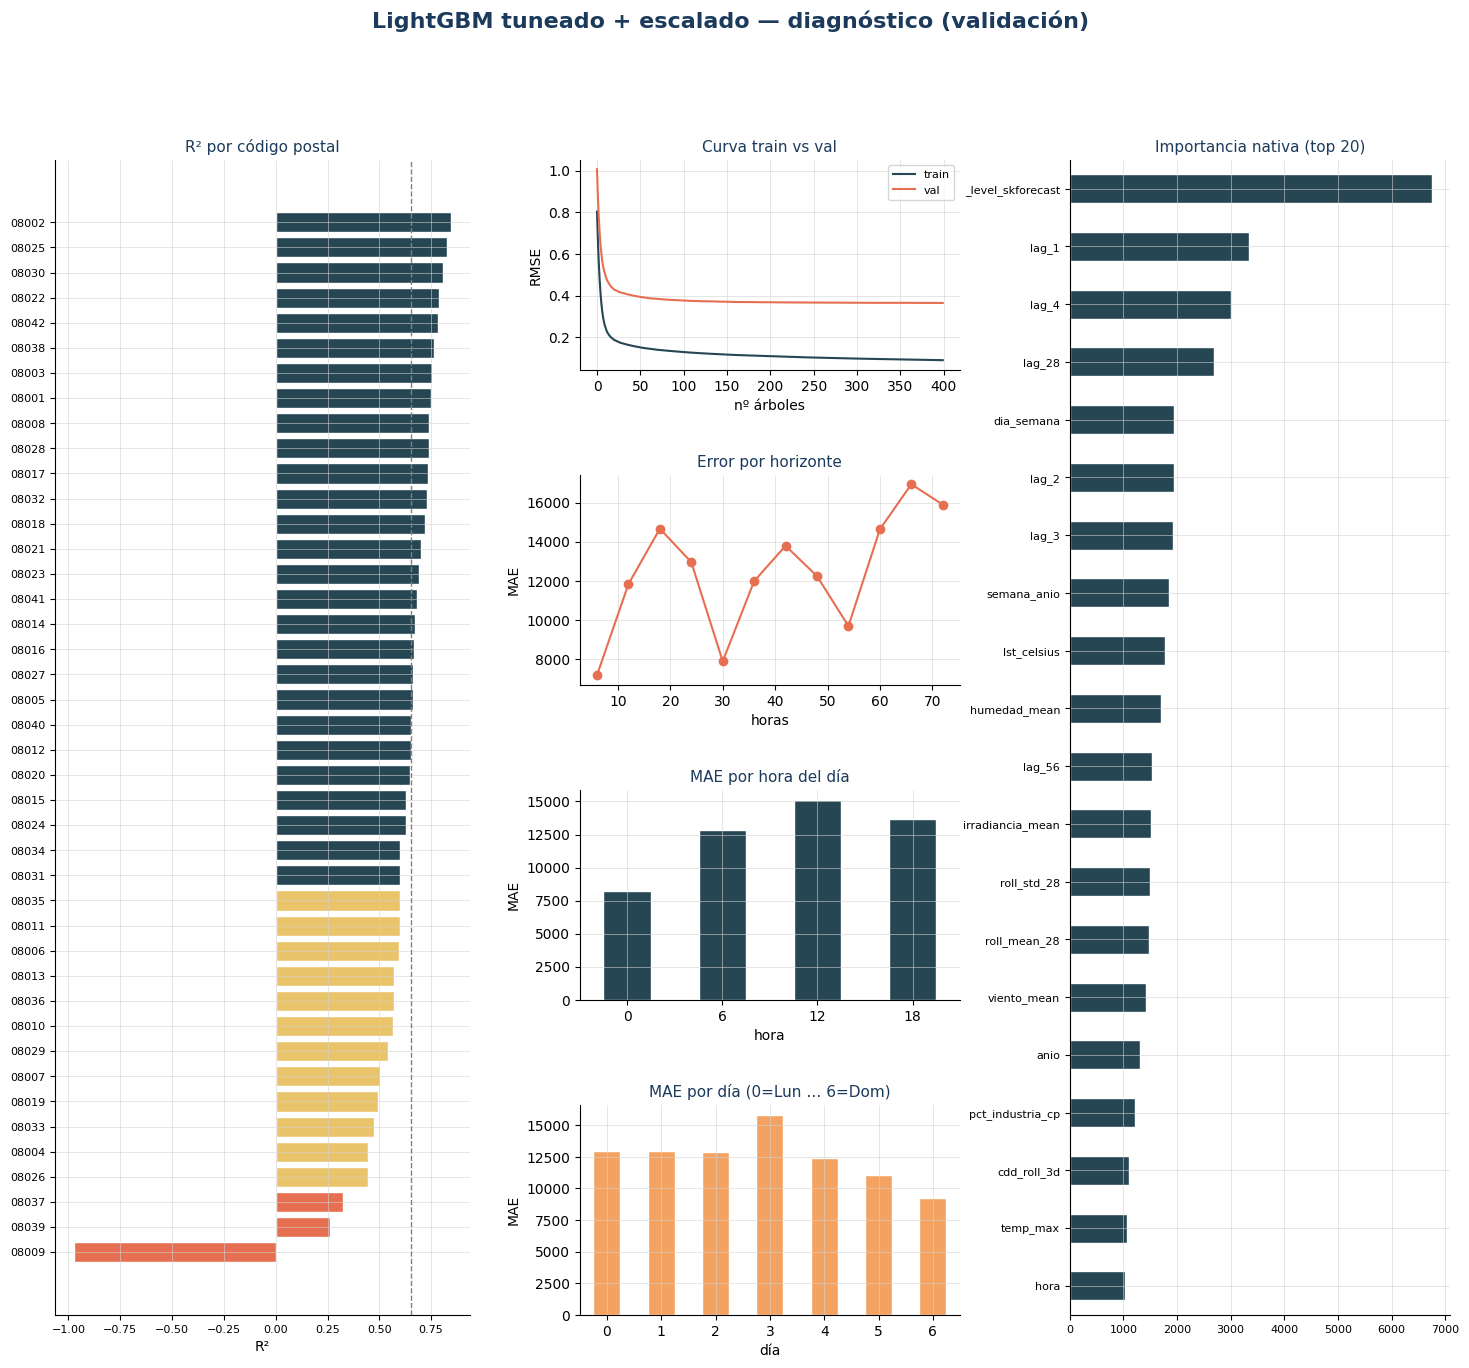

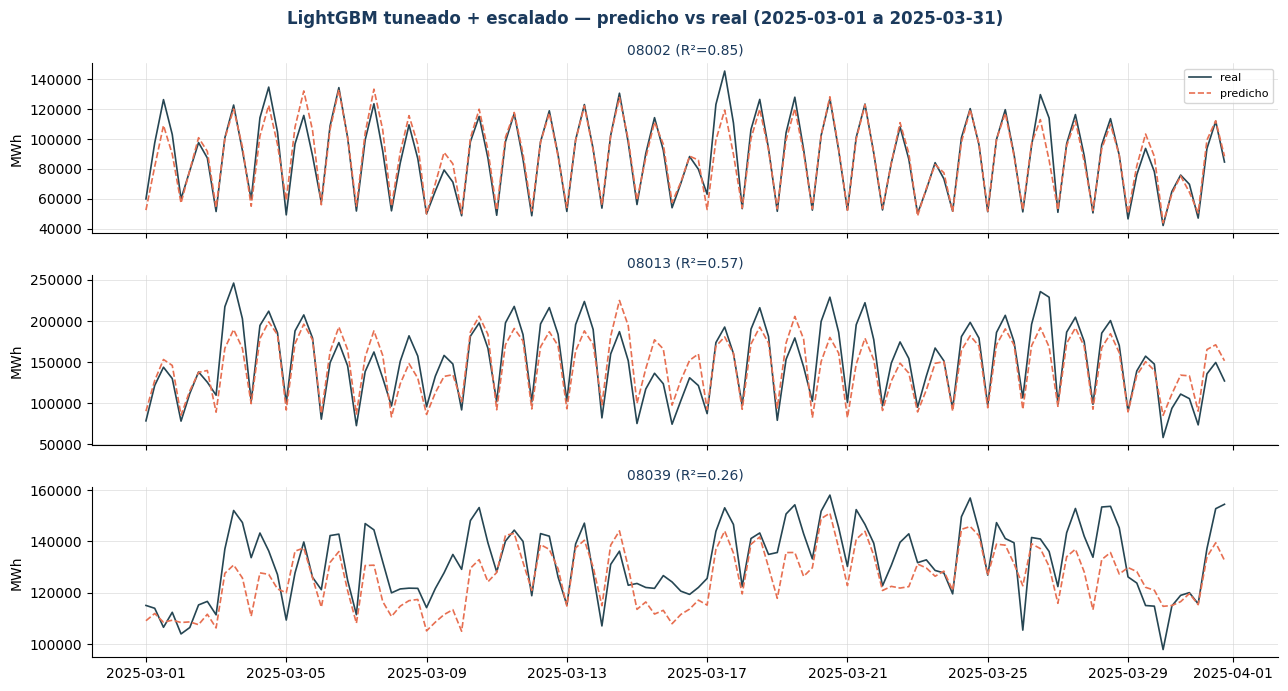

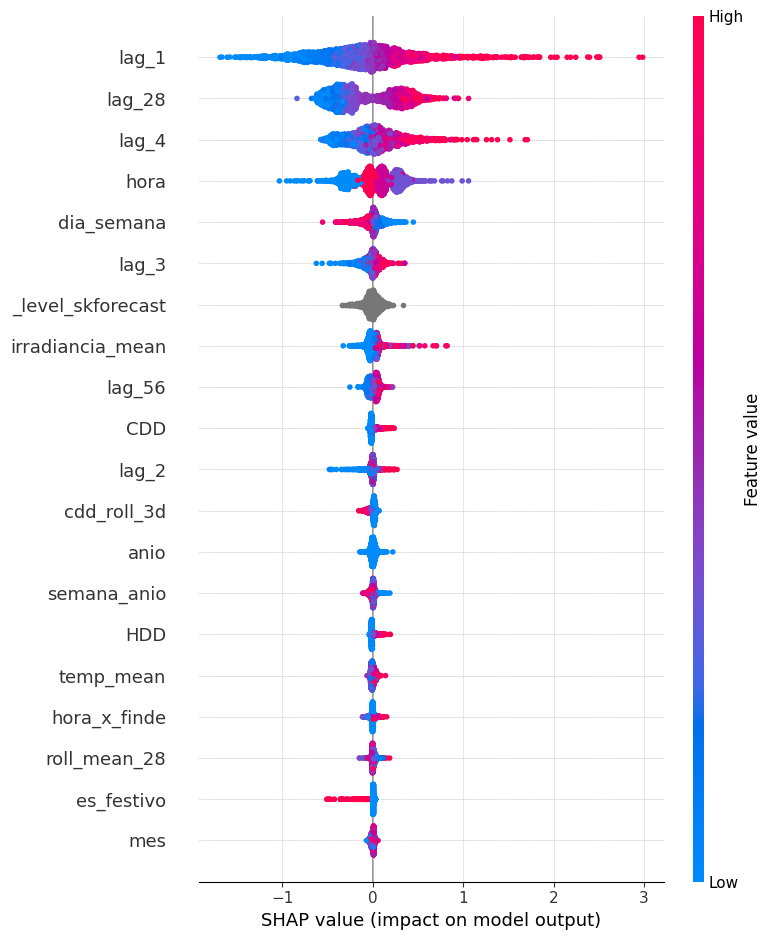

In [31]:
ml_val_tuned = revisar_resultados(pred_scaled, series_val, forecaster_scaled, exog_val,
                                  nombre='LightGBM tuneado + escalado')

In [32]:
comp = ml_val.merge(ml_val_tuned, on='cp', suffixes=('_base', '_tuned'))
comp['delta'] = (comp['r2_tuned'] - comp['r2_base']).round(3)
print("Los que MÁS empeoraron con tuning+escalado:")
print(comp.sort_values('delta')[['cp', 'r2_base', 'r2_tuned', 'delta']].head(6).to_string(index=False))
print("\nLos que MÁS mejoraron:")
print(comp.sort_values('delta', ascending=False)[['cp', 'r2_base', 'r2_tuned', 'delta']].head(6).to_string(index=False))

Los que MÁS empeoraron con tuning+escalado:
   cp  r2_base  r2_tuned  delta
08009 0.298099 -0.973575 -1.272
08037 0.533847  0.323103 -0.211
08007 0.613651  0.503024 -0.111
08013 0.624658  0.572455 -0.052
08006 0.607621  0.592953 -0.015
08008 0.754260  0.740923 -0.013

Los que MÁS mejoraron:
   cp  r2_base  r2_tuned  delta
08019 0.227114  0.491505  0.264
08014 0.471871  0.670073  0.198
08034 0.405463  0.602143  0.197
08040 0.496629  0.655144  0.159
08015 0.491152  0.630947  0.140
08029 0.401280  0.540048  0.139
